# **FICO® Xpress MoselPy: Introduction**

***intro.ipynb*** - Getting started with MoselPy using introductory Xpress application book examples.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

## Getting started with MoselPy

[MoselPy](https://pypi.org/project/moselpy/) lets you compile and run FICO&reg; Xpress Mosel models from Python, and exchange data bidirectionally. It enables you to combine Mosel's algebraic modeling language with Python's data and visualization ecosystem.

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_intro)

### When to use MoselPy

| Scenario | Use |
|----------|-----|
| You have existing Mosel models and want to execute them from Python | **MoselPy** |
| You prefer Mosel's algebraic syntax for building models | **MoselPy** |
| You want to distribute compiled `.bim` files for IP protection | **MoselPy** |
| You are building a new model directly in Python | [Xpress Python API](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/GUID-616C323F-05D8-3460-B0D7-80F77DA7D046.html) |

### Running Mosel models from Python

MoselPy offers two workflows for running a Mosel model:

**One-step:** compile and run in a single call; returns `(model, output_dict)`:

```python
model, output = mp.execute_model("model.mos", exec_params={"OUTFILE": "moselpy:"})
```

**Three-step:** compile once, load the binary, then run as many times as needed:

```python
# 1. Compile: Mosel source (.mos) → binary model (.bim)
mp.compile_model("model.mos", "model.bim")

# 2. Load the compiled model
model = mp.load_model("model.bim")

# 3. Run with optional parameters; results come back as a dict
output = model.run(exec_params={"OUTFILE": "moselpy:"})
```

In both cases, results exported via `initializations to "moselpy:"` are returned in `output`. The three-step workflow is preferred when the same model needs to run multiple times with different data (load once, run many times), and produces a distributable `.bim` binary. Note that `execute_model` does not write a `.bim` file to disk.

### Adapting a Mosel model for MoselPy

The models in this notebook are adapted versions of the original [Xpress application book examples](https://examples.xpress.fico.com/example.pl?id=mosel_app_intro). The four standard adaptations are:

1. **Add `DATASOURCE` for data file models:** Replace hardcoded filenames in `initializations from` with a `DATASOURCE` parameter. Override it with `exec_params={"DATASOURCE": "moselpy:"}` to inject data from Python via `input_data={...}`.

2. **Replace `writeln` output with `initializations to OUTFILE`:** Original models use `writeln()` to print results. Adapted models add `OUTFILE = ""` to a `parameters` block and write results with `initializations to OUTFILE`. Empty string writes to stdout when run standalone; `"moselpy:"` returns data to Python as a dict via `exec_params={"OUTFILE": "moselpy:"}`.

3. **Use `evaluation of` for scalar results:** Scalar expressions such as `getobjval` or `getsol(xs)` can be exported without an intermediate variable: `evaluation of getobjval as 'obj_val'`.

4. **Array results require a helper variable:** For arrays of decision variables, declare a `real` array (e.g., `sol_x: array(ITEMS) of real`), populate it after the solve with `forall(i in ITEMS) sol_x(i) := getsol(x(i))`, then include `sol_x` in the `initializations to` block.

### Models and data files

The Mosel source files (`.mos`) and compiled binary model files (`.bim`) for this notebook live in [`models/intro/`](models/intro/). Data files used by some models are in [`data/intro/`](data/intro/). The `.bim` files are generated by the first `compile_model()` call; they are platform-independent and can be distributed without the source.

### About this notebook

This notebook groups models that explain the basics of LP and MIP model development with Mosel, including data input/output patterns. The examples progress from a simple LP (chess sets) through integer programming and knapsack variants, to special ordered sets (SOS1/SOS2) and piecewise linear functions.

### Suppressing solver output

The setup cell below calls `mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")` before any model is loaded, silencing solver output globally for this notebook. This must be done before the first `load_model()` call; per-model `model.set_default_stream()` is available as an alternative for finer control. To retrieve solver logging output, enable it by setting the `XPRS_VERBOSE` control. The error stream (`mp.StreamType.ERROR`) should not be silenced - redirect it to Python if you need to capture runtime errors.

### MoselPy features demonstrated in this notebook

- **Single execution command vs compile-load-run sequence**: the Chess sets LP demonstrates both workflows side by side - `mp.execute_model()` for a one-shot run and the three-step sequence for reuse.
- **`exec_params` for output routing**: all models return results via `OUTFILE="moselpy:"` in `exec_params`; knapsack models also set `DATASOURCE="moselpy:"` to inject input data.
- **`input_data` with 1-indexed dicts**: the Knapsack with external data file passes item values and weights as Python dicts directly to `input_data`, replacing the `.dat` file for the notebook run.
- **`pd.DataFrame` as `input_data`**: the Knapsack with DataFrame input passes item data as a `pd.DataFrame`; MoselPy maps the index to the Mosel array index automatically.
- **`model.find_identifier(use_pandas=True)`**: the Function approximation (SOS2/piecewise linear) example retrieves the solution array as a pandas Series after the solve.

### Setup

Run the cell below to import MoselPy, matplotlib, NumPy, and pandas, and to set `MODELS` and `DATA`, the path variables pointing to the Mosel source files and data files used throughout this notebook. Other notebooks in this series place an equivalent setup cell right after the package installation cell; here it appears alongside the workflow description above.

In [ ]:
# On Linux, preload the Xpress solver library so the Mosel optimizer module
# (mmxprs) can resolve it at runtime.
import sys, os, glob, ctypes, xpresslibs
if sys.platform == "linux":
    for _lib in glob.glob(os.path.join(xpresslibs.solver_libs_dir, "libxprs.so*")):
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)

import moselpy as mp
from moselpy import ExecStatus
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/intro"
DATA   = "data/intro"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Chess sets (LP)

*Introductory example: Chapter 1 - Linear Programming*

> **Mosel model:** [`chess2_p.mos`](models/intro/chess2_p.mos)

A company makes two chess set sizes. Each **small set** requires 3 lathe-hours and 1 kg boxwood; each **large set** requires 2 lathe-hours and 3 kg boxwood. Available per week: 160 lathe-hours and 200 kg boxwood. Profit: \$5 per small set, \$20 per large set.

**Decision variables:** $x_s, x_l \geq 0$ (sets produced per week).

$$
\begin{align*}
\text{maximize}   \quad & 5\,x_s + 20\,x_l \\
\text{subject to} \quad & x_s + 3\,x_l \leq 200 \quad \text{(boxwood, kg)} \\
                          & 3\,x_s + 2\,x_l \leq 160 \quad \text{(lathe-hours)} \\
                          & x_s,\, x_l \geq 0
\end{align*}
$$

Beyond the optimal solution, post-solution LP queries reveal constraint and variable information:

- **Constraint activity** (`getact`): how much of each resource is actually used at the optimal solution
- **Dual value / shadow price** (`getdual`): how much the objective would improve if the right-hand side of a binding constraint were relaxed by one unit, e.g. a lathe shadow price of 6.67 means one extra lathe-hour is worth \$6.67 of profit
- **Reduced cost** (`getrcost`): how much the objective function coefficient of a non-basic variable must change before that variable enters the basis; zero for basic variables

**Adaptation from original:** `chess2.mos` uses `writeln()` for all output. In `chess2_p.mos`, every `writeln` call is replaced by an `evaluation of` expression inside `initializations to OUTFILE`, one line per result. This is the simplest adaptation: no helper variables needed when all outputs are scalars.

The cell below uses `mp.execute_model()`, which compiles and runs in a single call and returns a `(model, output)` tuple: `model` is the `Model` object (useful for inspecting `model.prob_status`, accessing identifiers, etc.) and `output` is a dict containing everything exported via `initializations to "moselpy:"`. This is the one-step alternative to the compile/load/run three-step workflow - convenient for a single run when no `.bim` file needs to be written to disk.

In [ ]:
model, output = mp.execute_model(f"{MODELS}/chess2_p.mos", exec_params={"OUTFILE": "moselpy:"})

if model.prob_status.is_solution_available:
    print(f"Optimal profit: ${output['obj_val']:.2f}")
    print(f"Small sets: {output['sol_xs']:.0f}   Large sets: {output['sol_xl']:.0f}")
    print()
    print(f"{'Constraint':<12} {'Activity':>10} {'Shadow price':>14}")
    print(f"{'Lathe':<12} {output['act_lathe']:>10.2f} {output['dual_lathe']:>14.4f}")
    print(f"{'Boxwood':<12} {output['act_boxwood']:>10.2f} {output['dual_boxwood']:>14.4f}")
    print()
    print(f"{'Variable':<12} {'Reduced cost':>14}")
    print(f"{'xs':<12} {output['rc_xs']:>14.4f}")
    print(f"{'xl':<12} {output['rc_xl']:>14.4f}")
    print()
    print(f"Model name : {model.name}")
    print(f"Exec status: {model.exec_status}")
    print(f"Optimal    : {model.prob_status.is_solution_optimal}")
else:
    print(f"No solution found ({model.prob_status})")

Optimal profit: $1333.33
Small sets: 0   Large sets: 67

Constraint     Activity   Shadow price
Lathe            133.33         0.0000
Boxwood          200.00         6.6667

Variable       Reduced cost
xs                  -1.6667
xl                  -0.0000

Model name : Chess 2
Exec status: ExecStatus.OK
Optimal    : True


## The knapsack problem (Burglar)

*Introductory examples: Chapters 2-3 - Integer Programming*

> **Mosel model:** [`burglari_p.mos`](models/intro/burglari_p.mos)

A burglar can carry at most $\text{WTMAX} = 102$ kg. Eight items have values $\text{VALUE}_i$ and weights $\text{WEIGHT}_i$. Which items to take?

| Item | camera | necklace | vase | picture | tv | video | chest | brick |
|------|--------|----------|------|---------|----|----|------|-------|
| VALUE | 15 | 100 | 90 | 60 | 40 | 15 | 10 | 1 |
| WEIGHT | 2 | 20 | 20 | 30 | 40 | 30 | 60 | 10 |

**Decision variables:** $\mathit{take}_i \in \{0,1\}$ (1 if item $i$ is taken, 0 otherwise).

$$
\begin{align*}
\text{maximize}   \quad & \sum_i \text{VALUE}_i\,\mathit{take}_i \\
\text{subject to} \quad & \sum_i \text{WEIGHT}_i\,\mathit{take}_i \leq \text{WTMAX} \\
                          & \mathit{take}_i \in \{0,1\} \quad \forall\, i
\end{align*}
$$

`burglari_p.mos` uses named string indices - a common pattern in real-world Mosel models.

**Workflow:** This section uses the three-step workflow (`compile_model` → `load_model` → `run`) to demonstrate the pattern explicitly. The compiled `.bim` file is reused by subsequent cells (the pandas data exchange and sensitivity analysis below), so loading once and running multiple times is the natural fit here.

In [ ]:
mp.compile_model(f"{MODELS}/burglari_p.mos", f"{MODELS}/burglari_p.bim")
model = mp.load_model(f"{MODELS}/burglari_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(exec_params={"OUTFILE": "moselpy:"})

print(f"Total value: ${output['obj_val']:.0f}")
taken = {item: v for item, v in output['sol_take'].items() if v > 0.5}
print(f"Items taken: {sorted(taken.keys())}")

Total value: $280
Items taken: ['camera', 'necklace', 'picture', 'vase', 'video']


### Checking solution status

After any `model.run()` call, check two properties before using results:

- **`model.exec_status`** (`ExecStatus.OK` / `ExecStatus.ERROR`): whether Mosel itself ran successfully (compiled, loaded, no runtime error). Check this first.
- **`model.prob_status`**: the optimizer's verdict on the mathematical problem. Key boolean flags: `is_solution_optimal`, `is_solution_feasible`, `is_problem_infeasible`, `is_problem_unbounded`.
- **`model.objective_value`**: the objective function value at the best solution found.

In [ ]:
# Check the solution status (good practice after any solve)
if model.exec_status == ExecStatus.OK:
    ps = model.prob_status
    if ps.is_solution_optimal:
        status = "optimal"
    elif ps.is_solution_feasible:
        status = "feasible (possibly not optimal)"
    elif ps.is_problem_infeasible:
        status = "infeasible"
    elif ps.is_problem_unbounded:
        status = "unbounded"
    else:
        status = "unknown"
    print(f"exec_status  : {model.exec_status}")
    print(f"prob_status  : {status}")
    print(f"objective    : {model.objective_value:.0f}")
else:
    print(f"Execution error: {model.exec_status}")

exec_status  : ExecStatus.OK
prob_status  : optimal
objective    : 280


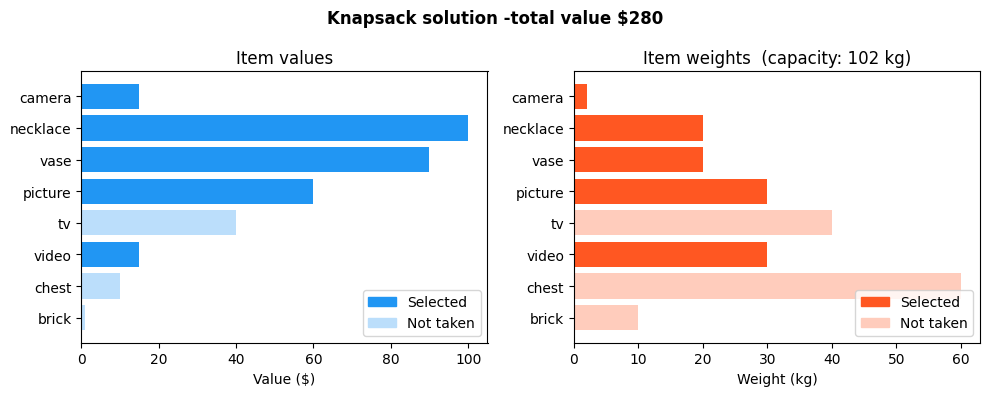

In [ ]:
# Item data (same as burglari_p.mos)
items   = ['camera', 'necklace', 'vase', 'picture', 'tv', 'video', 'chest', 'brick']
values  = [15, 100, 90, 60, 40, 15, 10, 1]
weights = [ 2,  20, 20, 30, 40, 30, 60, 10]
selected = set(taken.keys())

colors_v = ['#2196F3' if it in selected else '#BBDEFB' for it in items]
colors_w = ['#FF5722' if it in selected else '#FFCCBC' for it in items]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
y = range(len(items))

ax1.barh(list(y), values, color=colors_v)
ax1.set_yticks(list(y)); ax1.set_yticklabels(items)
ax1.set_xlabel('Value ($)'); ax1.set_title('Item values')
ax1.invert_yaxis()

ax2.barh(list(y), weights, color=colors_w)
ax2.set_yticks(list(y)); ax2.set_yticklabels(items)
ax2.set_xlabel('Weight (kg)'); ax2.set_title(f'Item weights  (capacity: 102 kg)')
ax2.invert_yaxis()

# Legend
legend = [mpatches.Patch(color='#2196F3', label='Selected'), mpatches.Patch(color='#BBDEFB', label='Not taken')]
ax1.legend(handles=legend, loc='lower right')
legend2 = [mpatches.Patch(color='#FF5722', label='Selected'), mpatches.Patch(color='#FFCCBC', label='Not taken')]
ax2.legend(handles=legend2, loc='lower right')

plt.suptitle(f'Knapsack solution -total value ${output["obj_val"]:.0f}', fontweight='bold')
plt.tight_layout(); plt.show()

### Two ways to read results from Python

`burglari_p.mos` has both `public` declarations and an `initializations to OUTFILE` block, making it a good place to compare the two standard approaches to reading results in MoselPy:

**Approach 1 - `initializations to OUTFILE`** (shown above; used in all subsequent examples)
The model exports results via `initializations to OUTFILE`; Python receives them as the dict returned by `model.run(exec_params={"OUTFILE": "moselpy:"})`. The model also runs correctly standalone, writing results to a file by default.

**Approach 2 - `public` + `find_identifier()`**
Declarations marked `public` in the model remain accessible from Python after the model runs. Retrieve them with `model.find_identifier(name)`, optionally as a pandas `Series` by passing `use_pandas=True`.

All subsequent examples use **Approach 1 only**. It is preferred because the model produces output when run standalone, without any Python wrapper.

In [ ]:
# Approach 2: find_identifier() accesses 'public' declarations directly from Python.
# use_pandas=True returns a pandas Series, convenient for further analysis.
sol_take_pd = model.find_identifier("sol_take", use_pandas=True)
print("Item selection (pandas Series):")
print(sol_take_pd.sort_values(ascending=False).rename("selected").to_frame().to_string())

Item selection (pandas Series):
          selected
camera         1.0
necklace       1.0
vase           1.0
picture        1.0
video          1.0
brick         -0.0
chest         -0.0
tv             0.0


## Knapsack with an external data file

> **Mosel model:** [`burglar2_p.mos`](models/intro/burglar2_p.mos)

`burglar2_p.mos` reads item data using `initializations from DATASOURCE`. Here the item data is defined directly in Python and injected at runtime via `input_data`. The `.dat` file (`burglar_p.dat`) is kept alongside the model for standalone execution.

`exec_params` overrides Mosel `parameters` block values before the model starts; use it for scalars such as file paths or mode flags. `input_data` is passed via `initializations from "moselpy:"` at runtime and can transfer scalars, arrays, sets, and pandas objects. Setting `DATASOURCE="moselpy:"` in `exec_params` redirects the `initializations from` block to read from Python instead of a file.

In [ ]:
VALUE  = {"camera": 15, "necklace": 100, "vase": 90, "picture": 60,
          "tv": 40, "video": 15, "chest": 10, "brick": 1}
WEIGHT = {"camera": 2, "necklace": 20, "vase": 20, "picture": 30,
          "tv": 40, "video": 30, "chest": 60, "brick": 10}

In [ ]:
mp.compile_model(f"{MODELS}/burglar2_p.mos", f"{MODELS}/burglar2_p.bim")
model = mp.load_model(f"{MODELS}/burglar2_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
                   input_data={"VALUE": VALUE, "WEIGHT": WEIGHT})

if model.prob_status.is_solution_available:
    print(f"Total value: ${output['obj_val']:.0f}")
    taken = {item: v for item, v in output['sol_take'].items() if v > 0.5}
    print(f"Items taken: {sorted(taken.keys())}")
else:
    print(f"No solution found ({model.prob_status})")

Total value: $280
Items taken: ['camera', 'necklace', 'picture', 'vase', 'video']


### Injecting data from Python with `exec_params`

Setting `exec_params={"DATASOURCE": "moselpy:"}` (used for scalars such as file paths) redirects the `initializations from` block to read data from Python instead of a file. Combined with `input_data`, this lets you pass any Python dict or pandas object directly to the model.

A key advantage: the model is loaded once and can be run as many times as needed with different data; no recompile or reload between runs.

In [ ]:
items   = {"camera": 15, "necklace": 100, "vase": 90, "picture": 60,
           "tv": 40, "video": 15, "chest": 10, "brick": 1}
weights = {"camera": 2, "necklace": 20, "vase": 20, "picture": 30,
           "tv": 40, "video": 30, "chest": 60, "brick": 10}

# Parametric run: how does the optimal selection change as the vase gets heavier?
# The model is already loaded; no recompile or reload needed between runs.
print(f"{'vase (kg)':>9}   {'value':>6}   items taken")
for vase_weight in [20, 40, 60, 80]:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"VALUE": items, "WEIGHT": dict(weights, vase=vase_weight)},
    )
    taken = sorted(k for k, v in out["sol_take"].items() if v > 0.5)
    print(f"{vase_weight:>6} kg   {out['obj_val']:>6.0f}   {taken}")

vase (kg)    value   items taken
    20 kg      280   ['camera', 'necklace', 'picture', 'vase', 'video']
    40 kg      266   ['brick', 'camera', 'necklace', 'picture', 'vase']
    60 kg      216   ['brick', 'camera', 'necklace', 'picture', 'tv']
    80 kg      216   ['brick', 'camera', 'necklace', 'picture', 'tv']


## Knapsack with DataFrame input

> **Mosel model:** [`burglar_df_p.mos`](models/intro/burglar_df_p.mos)

`burglar_df_p.mos` stores item data in a 2D Mosel array `I(FIELDS, ITEMS)` where `FIELDS = {'value', 'weight'}` and `ITEMS` is the set of item names. This layout maps directly to a `pd.DataFrame` — rows are fields, columns are items. Passing the DataFrame via `input_data` is the most natural way to inject tabular item data from Python into Mosel.

Both `FIELDS` and `ITEMS` are `set of string` in the model and auto-populate from the DataFrame row and column labels when the data is passed.

In [ ]:
item_df = pd.DataFrame(
    {"camera":    [15,  2],
     "necklace":  [100, 20],
     "vase":      [90,  20],
     "picture":   [60,  30],
     "tv":        [40,  40],
     "video":     [15,  30],
     "chest":     [10,  60],
     "brick":     [1,   10]},
    index=["value", "weight"],
)
print(item_df.to_string())

        camera  necklace  vase  picture  tv  video  chest  brick
value       15       100    90       60  40     15     10      1
weight       2        20    20       30  40     30     60     10


Pass the `pd.DataFrame` via `input_data`. MoselPy maps rows to `FIELDS` and columns to `ITEMS` automatically.

In [ ]:
mp.compile_model(f"{MODELS}/burglar_df_p.mos", f"{MODELS}/burglar_df_p.bim")
model = mp.load_model(f"{MODELS}/burglar_df_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
                   input_data={"I": item_df})

if model.prob_status.is_solution_available:
    print(f"Total value: ${output['obj_val']:.0f}")
    taken = {item: v for item, v in output['sol_take'].items() if v > 0.5}
    print(f"Items taken: {sorted(taken.keys())}")
else:
    print(f"No solution found ({model.prob_status})")

Total value: $280
Items taken: ['camera', 'necklace', 'picture', 'vase', 'video']


## Price breaks: all-item discount

*Introductory example: Chapter 4 - Special Ordered Sets*

> **Mosel models:** [`pricebrai_p.mos`](models/intro/pricebrai_p.mos), [`pricebrai2_p.mos`](models/intro/pricebrai2_p.mos)

We fix the purchased quantity to `DEM`=150 units to make the code runnable. Unit price depends on the total quantity purchased:

| Band | Quantity range | Unit cost |
|------|---------------|-----------|
| 1 | 0-50 | 1.00 |
| 2 | 50-120 | 0.70 |
| 3 | 120-200 | 0.50 |

All units are charged at whichever band rate applies to the total quantity bought.

**Decision variables:** $x_i \geq 0$ (quantity bought at price $\text{COST}_i$), $b_i \in \{0,1\}$ (active price band).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{i=1}^{3} \text{COST}_i\,x_i \\
\text{subject to} \quad & \sum_{i=1}^{3} x_i = \text{DEM} \\
                          & B_{i-1}\,b_i \leq x_i \leq B_i\,b_i \quad \forall\,i \\
                          & \sum_{i=1}^{3} b_i = 1, \quad b_i \in \{0,1\}
\end{align*}
$$

Data (`DEM`, `B`, `COST`) is read via a `DATASOURCE` parameter, which lets us pass Python values directly to Mosel using `input_data`. Mosel arrays are 1-indexed by default, but `B` is declared as `array(0..NB)` so its keys run from 0 to 3 - the dict passed for `B` must match that range.

In [ ]:
B    = [0, 50, 120, 200]   # price band breakpoints (reused in viz below)
COST = [1.0, 0.7, 0.5]
DEM  = 150

mp.compile_model(f"{MODELS}/pricebrai_p.mos", f"{MODELS}/pricebrai_p.bim")
model = mp.load_model(f"{MODELS}/pricebrai_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={
        "DEM":  DEM,
        "B":    {i: B[i] for i in range(len(B))},
        "COST": {i + 1: COST[i] for i in range(len(COST))},
    },
)

if model.prob_status.is_solution_available:
    print(f"Total cost: {output['obj_val']:.2f}  (avg per unit: {output['obj_val']/DEM:.4f})")
    print(f"{'Band':<6} {'Quantity':>10} {'Unit cost':>10}")
    for i in range(1, 4):
        print(f"{i:<6} {output['sol_x'][i]:>10.2f} {COST[i-1]:>10.2f}")
else:
    print(f"No solution found ({model.prob_status})")

Total cost: 75.00  (avg per unit: 0.5000)
Band     Quantity  Unit cost
1            0.00       1.00
2            0.00       0.70
3          150.00       0.50


### All-item discount via `pwlin` (pricebrai2_p.mos)

`pricebrai2_p.mos` reformulates the same problem using a `pwlin` piecewise-linear expression (requires `mmxnlp`). The model reduces to a single continuous variable $x$ with a piecewise cost function.

As with `chess2_p.mos`, we use `execute_model` for a one-step run.

In [ ]:
model, output = mp.execute_model(f"{MODELS}/pricebrai2_p.mos", exec_params={"OUTFILE": "moselpy:"})

if model.prob_status.is_solution_available:
    print(f"Total cost: {output['obj_val']:.2f}  (avg per unit: {output['obj_val']/DEM:.4f})")
    print(f"Quantity bought: {output['sol_x']:.0f}")
else:
    print(f"No solution found ({model.prob_status})")

Total cost: 75.00  (avg per unit: 0.5000)
Quantity bought: 150


## Price breaks: incremental discount

*Introductory example: Chapter 4 - Special Ordered Sets*

> **Mosel models:** [`pricebrinc_p.mos`](models/intro/pricebrinc_p.mos), [`pricebrinc2_p.mos`](models/intro/pricebrinc2_p.mos), [`pricebrinc3_p.mos`](models/intro/pricebrinc3_p.mos)

Same quantity bands as above, but pricing is now **incremental**: the first 50 units cost 0.80 each, the next 70 (up to 120) cost 0.50 each, and anything beyond 120 costs 0.30 each.

`pricebrinc_p.mos` models this with an SOS2 (Special Ordered Set of Type 2). At each of the four breakpoints $B_0, B_1, B_2, B_3$, a weight variable $w_i \geq 0$ is introduced; $\text{CBP}_i$ is the total cost of buying exactly $B_i$ units. The SOS2 constraint allows **at most two adjacent** $w_i$ to be non-zero -this forces the solution onto one linear segment of the piecewise cost function.

**Decision variables:** $x \geq 0$ (total quantity), $w_i \geq 0$, $i = 0..3$ (SOS2 interpolation weights).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{i=0}^{3} \text{CBP}_i\, w_i \\
\text{subject to} \quad & x = \text{DEM} \\
                          & x = \sum_{i=0}^{3} B_i\, w_i \\
                          & \sum_{i=0}^{3} w_i = 1, \quad w \in \text{SOS2}
\end{align*}
$$

A key subtlety: `makesos2` is used instead of `is_sos2` because the reference row contains a zero-valued coefficient ($B_0 = 0$), which `is_sos2` cannot handle correctly.

### Injecting data from Python

`pricebrinc_p.mos` accepts its data via a `DATASOURCE` parameter (defaulting to a `.dat` file when run standalone). Passing `exec_params={"DATASOURCE": "moselpy:"}` redirects the `initializations from DATASOURCE` block to read from Python instead. The `input_data` dict then maps Python values directly to Mosel identifiers by name.

This is the standard MoselPy pattern for pushing data into a model at runtime - no `.dat` file needed. The three-step workflow is used here because the loaded `model` is reused in the parametric run in the next cell.

In [ ]:
# Three-step workflow: model is loaded once here and reused in the parametric loop below
COST_INC = [0.8, 0.5, 0.3]   # unit cost per band (reused in viz below)

mp.compile_model(f"{MODELS}/pricebrinc_p.mos", f"{MODELS}/pricebrinc_p.bim")
model = mp.load_model(f"{MODELS}/pricebrinc_p.bim")

# exec_params={"DATASOURCE": "moselpy:"} redirects 'initializations from DATASOURCE'
# to read from Python; input_data maps Python values to Mosel identifiers
output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={
        "DEM":  DEM,
        "B":    {i: b for i, b in enumerate(B)},
        "COST": {i+1: c for i, c in enumerate(COST_INC)},
    },
)

if model.prob_status.is_solution_available:
    print(f"Total cost: {output['obj_val']:.2f}  (avg per unit: {output['obj_val']/DEM:.4f})")
    print(f"Quantity bought: {output['sol_x']:.0f}")
    print(f"SOS2 weights: { {i: f'{v:.4f}' for i,v in output['sol_w'].items()} }")
else:
    print(f"No solution found ({model.prob_status})")

Total cost: 84.00  (avg per unit: 0.5600)
Quantity bought: 150
SOS2 weights: {0: '0.0000', 1: '0.0000', 2: '0.6250', 3: '0.3750'}


### Varying demand

When the same model runs many times with different data, the three-step workflow pays off: compile and load once, then call `run()` in a loop. `run()` resets the model automatically before each execution - no manual `reset()` needed.

In [ ]:
demands = [50, 80, 120, 150, 180, 200]
rows = []
for dem in demands:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={
            "DEM":  dem,
            "B":    {i: b for i, b in enumerate(B)},
            "COST": {i+1: c for i, c in enumerate(COST_INC)},
        },
    )
    rows.append({"demand": dem, "total_cost": out["obj_val"], "avg_unit_cost": out["obj_val"] / dem})

df = pd.DataFrame(rows).set_index("demand")
print(df.to_string(float_format="{:.4f}".format))

        total_cost  avg_unit_cost
demand                           
50         40.0000         0.8000
80         55.0000         0.6875
120        75.0000         0.6250
150        84.0000         0.5600
180        93.0000         0.5167
200        99.0000         0.4950


### Incremental discount with binary variables (pricebrinc2_p.mos)

An alternative formulation of the same incremental problem using explicit binary variables $b_i$ instead of SOS2.

In [ ]:
model, output = mp.execute_model(f"{MODELS}/pricebrinc2_p.mos", exec_params={"OUTFILE": "moselpy:"})

if model.prob_status.is_solution_available:
    print(f"Total cost: {output['obj_val']:.2f}  (avg per unit: {output['obj_val']/DEM:.4f})")
    print(f"{'Band':<6} {'Quantity':>10} {'Unit cost':>10}")
    for i in range(1, 4):
        print(f"{i:<6} {output['sol_x'][i]:>10.2f} {COST_INC[i-1]:>10.2f}")
else:
    print(f"No solution found ({model.prob_status})")

Total cost: 84.00  (avg per unit: 0.5600)
Band     Quantity  Unit cost
1           50.00       0.80
2           70.00       0.50
3           30.00       0.30


### Incremental discount via `pwlin` (pricebrinc3_p.mos)

A third formulation using a `pwlin` piecewise-linear expression (requires `mmxnlp`). The cost function is specified directly as a piecewise linear function of the total quantity $x$.

In [ ]:
model, output = mp.execute_model(f"{MODELS}/pricebrinc3_p.mos", exec_params={"OUTFILE": "moselpy:"})

if model.prob_status.is_solution_available:
    print(f"Total cost: {output['obj_val']:.2f}  (avg per unit: {output['obj_val']/DEM:.4f})")
    print(f"Quantity bought: {output['sol_x']:.0f}")
else:
    print(f"No solution found ({model.prob_status})")

Total cost: 84.00  (avg per unit: 0.5600)
Quantity bought: 150


### Visualizing the two pricing models

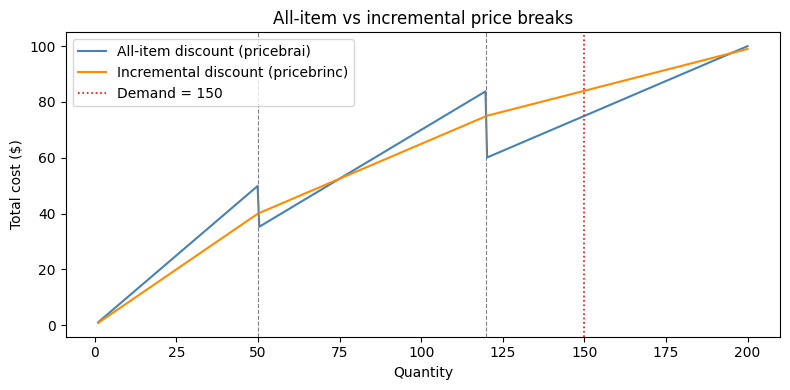

In [ ]:
# B, COST defined in the all-item section; COST_INC defined in the SOS2 section
cbp = [0]
for i in range(3):
    cbp.append(cbp[-1] + COST_INC[i] * (B[i+1] - B[i]))

def allitem_cost(q):
    for i in range(2, -1, -1):
        if q >= B[i]:
            return COST[i] * q
    return COST[0] * q

def incremental_cost(q):
    for i in range(3):
        if q <= B[i+1]:
            return cbp[i] + COST_INC[i] * (q - B[i])
    return cbp[3]

qty = np.linspace(1, 200, 400)
ai  = [allitem_cost(q) for q in qty]
inc = [incremental_cost(q) for q in qty]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(qty, ai,  label='All-item discount (pricebrai)',     color='steelblue')
ax.plot(qty, inc, label='Incremental discount (pricebrinc)', color='darkorange')
for b in B[1:-1]:
    ax.axvline(b, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(150, color='red', linestyle=':', linewidth=1.2, label='Demand = 150')
ax.set_xlabel('Quantity'); ax.set_ylabel('Total cost ($)')
ax.set_title('All-item vs incremental price breaks')
ax.legend(); plt.tight_layout(); plt.show()

## Function approximation with SOS2

*Introductory example: Chapter 5 - Piecewise Linear Programming*

> **Mosel models:** [`approx_p.mos`](models/intro/approx_p.mos), [`approx2_p.mos`](models/intro/approx2_p.mos)

Minimize a piecewise linear function $f(x)$ defined by five breakpoints:

| $i$ | $\text{R}_i$ | $\text{F}_i$ |
|-----|-------|-------|
| 1 | 1.0 | 2.0 |
| 2 | 2.2 | 3.2 |
| 3 | 3.4 | 1.4 |
| 4 | 4.8 | 2.5 |
| 5 | 6.5 | 0.8 |

**Decision variables:** $x, f \geq 0$ (position and function value), $y_i \geq 0$ (SOS2 interpolation weights at each breakpoint).

$$
\begin{align*}
\text{minimize}   \quad & f \\
\text{subject to} \quad & f = \sum_{i=1}^{5} \text{F}_i\,y_i \\
                          & x = \sum_{i=1}^{5} \text{R}_i\,y_i, \quad \sum_{i=1}^{5} y_i = 1 \\
                          & R_1 \leq x \leq R_5, \quad y \in \text{SOS2}
\end{align*}
$$

The breakpoint coordinates ($R_i$, $F_i$) are defined in Python as plain lists and injected into the model via `input_data`. The model receives them through an `initializations from DATASOURCE` block, with `DATASOURCE` overridden to `"moselpy:"` at runtime - the same pattern used throughout these examples. This makes it trivial to experiment with different breakpoint configurations without editing the Mosel source. The model also ships with `approx_p.dat` and can run standalone with `mosel exec approx_p.mos`.

Optimal f: 0.8000  at x = 6.5000


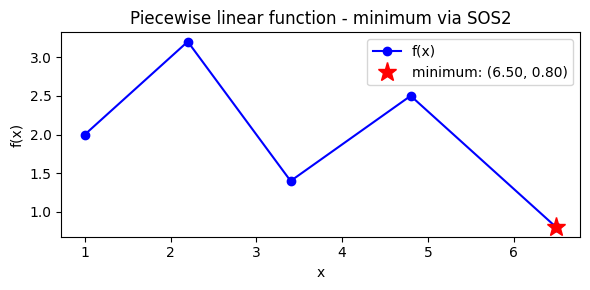

In [ ]:
mp.compile_model(f"{MODELS}/approx_p.mos", f"{MODELS}/approx_p.bim")
model = mp.load_model(f"{MODELS}/approx_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

# Breakpoint data defined in Python and passed to the model via input_data
R = [1.0, 2.2, 3.4, 4.8, 6.5]
F = [2.0, 3.2, 1.4, 2.5, 0.8]

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"R": {i+1: v for i, v in enumerate(R)},
                "F": {i+1: v for i, v in enumerate(F)}},
)

if model.prob_status.is_solution_available:
    print(f"Optimal f: {output['sol_f']:.4f}  at x = {output['sol_x']:.4f}")
else:
    print(f"No solution found ({model.prob_status})")

# Visualize the piecewise linear function and the optimum
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(R, F, 'b-o', label='f(x)')
ax.plot(output['sol_x'], output['sol_f'], 'r*', markersize=14, label=f"minimum: ({output['sol_x']:.2f}, {output['sol_f']:.2f})")
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Piecewise linear function - minimum via SOS2')
ax.legend(); plt.tight_layout(); plt.show()

### Piecewise linear approximation via `pwlin` (approx2_p.mos)

`approx2_p.mos` uses a `pwlin` expression (requires `mmxnlp`) to state the same piecewise linear constraint - a more compact formulation handled natively by the MIP solver. The same breakpoint data from the cell above (`R` and `F`) is reused and passed under the model's variable names `X` and `FX`.

In [ ]:
# Reuse the same breakpoint data from above, passed as X and FX
model, output = mp.execute_model(
    f"{MODELS}/approx2_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"X":  {i+1: v for i, v in enumerate(R)},
                "FX": {i+1: v for i, v in enumerate(F)}},
)
if model.prob_status.is_solution_available:
    print(f"Optimal f: {output['sol_f']:.4f}  at x = {output['sol_x']:.4f}")
else:
    print(f"No solution found ({model.prob_status})")

Optimal f: 0.8000  at x = 6.5000
